# Dataset Setup & Prerequisites

This notebook utilizes the same **Credit Card Fraud Detection** dataset (`creditcard.csv`) used in previous notebooks.

### 1. Upload the Data
Before running the code, ensure the dataset is uploaded to Databricks:
1. Click **+ New** (top left sidebar) > **Data**.
2. Select **Create or modify table**.
3. Upload your local `creditcard.csv` file.
4. Ensure the created table is named `creditcard` (saved in the `default` schema).

### 2. Verify Access
The notebook loads data using the following command. If you saved it elsewhere, update the path accordingly:
`dataframe = spark.read.table("workspace.default.creditcard")`


In [0]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix, RocCurveDisplay
from sklearn.model_selection import KFold
import mlflow
from mlflow.models import infer_signature


In [0]:
dataframe = spark.read.table("workspace.default.creditcard")
df=dataframe.toPandas()


In [0]:
df = df.drop("Time", axis=1) # Cette colonne n'apporte rien à notre analyse 
df.head()


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


<Axes: xlabel='Class', ylabel='count'>

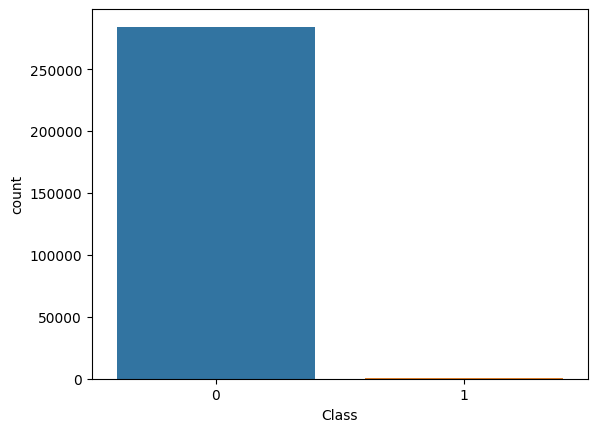

In [0]:
sns.countplot(x='Class',data=df)


In [0]:
normal = df[df.Class == 0].sample(frac=0.5,random_state=2020).reset_index(drop=True)
anomaly = df[df.Class == 1]


In [0]:
print(f"Normal: {normal.shape}")
print(f"Anomaly: {anomaly.shape}")


Normal: (142158, 30)
Anomaly: (492, 30)


In [0]:
normal_train, normal_test = train_test_split(normal,test_size = 0.2, random_state = 2020)
anomaly_train, anomaly_test = train_test_split(anomaly, test_size = 0.2, random_state = 2020)
normal_train, normal_validate = train_test_split(normal_train,test_size = 0.25, random_state = 2020)
anomaly_train, anomaly_validate = train_test_split(anomaly_train, test_size = 0.25, random_state = 2020)


In [0]:
x_train = pd.concat((normal_train, anomaly_train))
x_test = pd.concat((normal_test, anomaly_test))
x_validate = pd.concat((normal_validate, anomaly_validate))


In [0]:
y_train = np.array(x_train["Class"])
y_test = np.array(x_test["Class"])
y_validate = np.array(x_validate["Class"])


In [0]:
x_train = x_train.drop("Class", axis=1)
x_test = x_test.drop("Class", axis=1)
x_validate = x_validate.drop("Class", axis=1)


In [0]:
print("Training sets:\nx_train: {} \ny_train:{}".format(x_train.shape, y_train.shape))
print("\nTesting sets:\nx_test: {} \ny_test:{}".format(x_test.shape, y_test.shape))
print("\nValidation sets:\nx_validate: {} \ny_validate: {}".format(x_validate.shape, y_validate.shape))


Training sets:
x_train: (85588, 29) 
y_train:(85588,)

Testing sets:
x_test: (28531, 29) 
y_test:(28531,)

Validation sets:
x_validate: (28531, 29) 
y_validate: (28531,)


In [0]:
scaler = StandardScaler()
scaler.fit(pd.concat((normal, anomaly)).drop("Class", axis=1))


StandardScaler()

In [0]:
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)
x_validate = scaler.transform(x_validate)


In [0]:
def train(sk_model, x_train, y_train):
    sk_model = sk_model.fit(x_train, y_train)
    train_acc = sk_model.score(x_train, y_train)
    mlflow.log_metric("train_acc", train_acc)
    print(f"Train Accuracy: {train_acc:.3%}")
    

In [0]:
def evaluate(sk_model, x_test, y_test):
    eval_acc = sk_model.score(x_test, y_test)
    preds = sk_model.predict(x_test)
    auc_score = roc_auc_score(y_test, preds)
    mlflow.log_metric("eval_acc", eval_acc) # Nous avons fait la même chose pour l'accuracy de test (evaluation)
    mlflow.log_metric("auc_score", auc_score)# Aussi pour l'AUC score 
    print(f"Auc Score: {auc_score:.3%}")
    print(f"Eval Accuracy: {eval_acc:.3%}")
    roc_plot = RocCurveDisplay.from_estimator(sk_model, x_test, y_test, name='Scikit-learn ROC Curve')
    plt.savefig("sklearn_roc_plot.png")
    plt.show()
    plt.clf()
    conf_matrix = confusion_matrix(y_test, preds)
    ax = sns.heatmap(conf_matrix, annot=True,fmt='g')
    ax.invert_xaxis()
    ax.invert_yaxis()
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title("Confusion Matrix")
    plt.savefig("sklearn_conf_matrix.png")
    # Nous avons dit à MLflow de sauvegarder ces deux figure afin de les consulter à chaque exécution d'une façon organisée comme nous allons le voir plus loin dans cet atelier  
    mlflow.log_artifact("sklearn_roc_plot.png")
    mlflow.log_artifact("sklearn_conf_matrix.png")
    

Starting run...


/databricks/python/lib/python3.11/site-packages/sklearn/utils/optimize.py:211: ConvergenceWarning: newton-cg failed to converge. Increase the number of iterations.
  warnings.warn(


Train Accuracy: 99.893%
Auc Score: 85.341%
Eval Accuracy: 99.874%


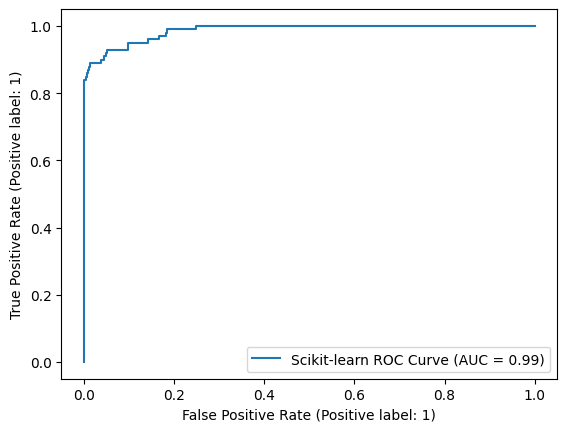

Model run finished:  8c2c21cf2b1749a890f6fb0184ad5277


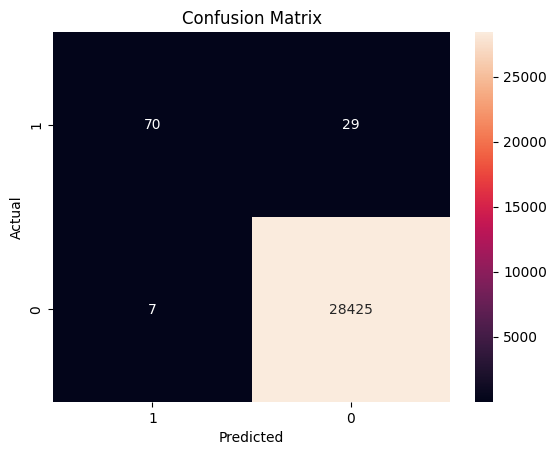

In [0]:
sk_model = LogisticRegression(
    random_state=None,
    max_iter=10,
    solver='newton-cg'
)

print("Starting run...")
with mlflow.start_run():
    train(sk_model, x_train, y_train)
    evaluate(sk_model, x_test, y_test)

    signature = infer_signature(
        x_train,
        sk_model.predict(x_train)
    )

    # REMOVED: set_registry_uri and registered_model_name (Not supported on Community Edition)
    mlflow.sklearn.log_model(
        sk_model,
        "log_reg_model",
        signature=signature
    )
    
    print("Model run finished: ", mlflow.active_run().info.run_uuid)
    

Starting Hyperparameter tuning...
Best Hyperparameters: {'C': 95.56385850092407, 'penalty': 'l1', 'solver': 'liblinear'}
Auc Score: 85.341%
Eval Accuracy: 99.874%


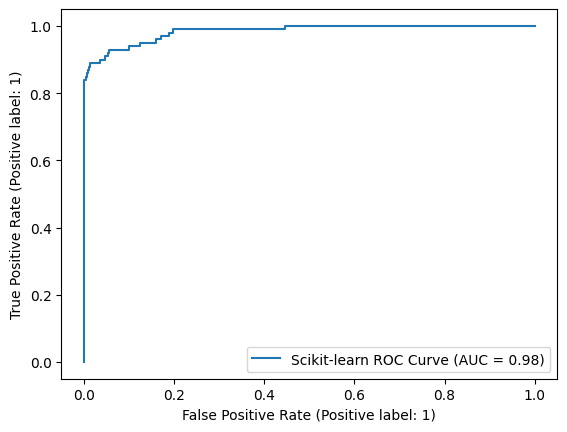

2025/12/14 22:59:37 WARNING mlflow.models.model: Model logged without a signature. Signatures will be required for upcoming model registry features as they validate model inputs and denote the expected schema of model outputs. Please visit https://www.mlflow.org/docs/2.11.4/models.html#set-signature-on-logged-model for instructions on setting a model signature on your logged model.


Run ID:  5ab058025c21481282bd6569097a0c27


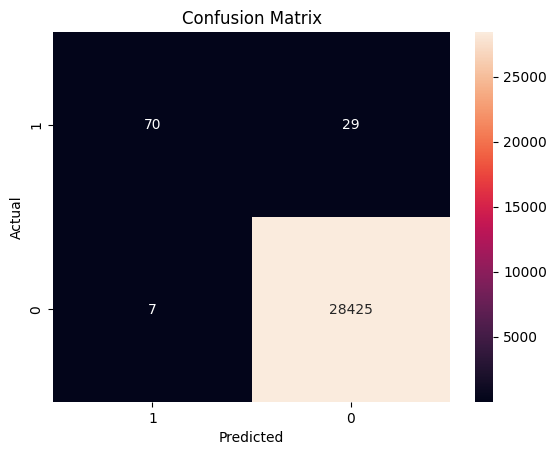

In [0]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform
from sklearn.linear_model import LogisticRegression

# Use a standard CV instead of Repeated (Faster)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=1)

model = LogisticRegression(max_iter=500) # Increased max_iter to prevent convergence warnings

space = [
    # Config 1: Solvers that support L2 only
    {
        'solver': ['lbfgs', 'newton-cg'],
        'penalty': ['l2'],
        'C': loguniform(1e-5, 100)
    },
    # Config 2: Solver that supports L1 and L2
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': loguniform(1e-5, 100)
    }
]

# Reduce n_iter for a test run
# 20 iterations * 3 folds = 60 fits (vs 15,000 fits previously)
search = RandomizedSearchCV(
    model, 
    space, 
    n_iter=20,  # CHANGED from 500
    scoring='accuracy', 
    n_jobs=-1, 
    cv=cv, 
    random_state=1
)

with mlflow.start_run(run_name="Logistic Regression"):
    print("Starting Hyperparameter tuning...")
    sk_model = search.fit(x_train, y_train)
    
    print('Best Hyperparameters: %s' % sk_model.best_params_)
    mlflow.log_params(sk_model.best_params_)
    
    evaluate(sk_model, x_test, y_test)
    
    mlflow.sklearn.log_model(sk_model.best_estimator_, "log_reg_model")
    print("Run ID: ", mlflow.active_run().info.run_uuid)


In [0]:
all_runs = mlflow.search_runs(max_results=10)  # Note : This is a pandas dataframe
display(all_runs)


run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.auc_score,metrics.eval_acc,params.solver,params.C,params.penalty,tags.mlflow.databricks.cluster.info,tags.mlflow.source.name,tags.mlflow.user,tags.mlflow.runName,tags.mlflow.runColor,tags.mlflow.databricks.notebook.commandID,tags.mlflow.databricks.workspaceURL,tags.mlflow.databricks.notebookRevisionID,tags.mlflow.log-model.history,tags.mlflow.databricks.cluster.libraries,tags.mlflow.databricks.cluster.id,tags.mlflow.databricks.notebookID,tags.mlflow.databricks.notebookPath,tags.mlflow.databricks.workspaceID,tags.mlflow.databricks.webappURL,tags.mlflow.source.type
5ab058025c21481282bd6569097a0c27,1363937468949169,FINISHED,dbfs:/databricks/mlflow-tracking/1363937468949169/5ab058025c21481282bd6569097a0c27/artifacts,2025-12-14T22:59:18.188Z,2025-12-14T22:59:38.315Z,0.8534122528037835,0.9987382145736217,liblinear,95.56385850092407,l1,"{""cluster_name"":"""",""spark_version"":""client.2.5-aarch64-scala2.12"",""autotermination_minutes"":120}",/Users/ilyasboudhaine1@gmail.com/Drafts/5. MLflow-DataBricks,ilyasboudhaine1@gmail.com,victorious-gull-39,#da4c4c,1765750255903_5258183556758649385_c6da3d4129ba494e800bdddadbf6e42c,https://dbc-91a64709-08e0.cloud.databricks.com,1765753178401,"[{""artifact_path"":""log_reg_model"",""flavors"":{""python_function"":{""predict_fn"":""predict"",""model_path"":""model.pkl"",""loader_module"":""mlflow.sklearn"",""env"":{""conda"":""conda.yaml"",""virtualenv"":""python_env.yaml""},""python_version"":""3.11.10""},""sklearn"":{""pickled_model"":""model.pkl"",""sklearn_version"":""1.3.0"",""serialization_format"":""cloudpickle"",""code"":null}},""utc_time_created"":""2025-12-14 22:59:36.259796""}]","{""installable"":[],""redacted"":[]}",1214-221054-eayyjrz1-v2n,1363937468949163,/Users/ilyasboudhaine1@gmail.com/Drafts/5. MLflow-DataBricks,3854114956778625,https://dbc-91a64709-08e0.cloud.databricks.com,NOTEBOOK


TAF: 

1. Réexécutez la cellule 18 en utilisant d'autres modèle ML de SKlearn 
2. Comparez vos résultats en utilisant l'outil de comparaison de MLFlow


Starting Fast Random Forest tuning...
Best Params: {'n_estimators': 50, 'min_samples_split': 10, 'max_depth': 10}
Train Accuracy: 99.942%
Auc Score: 88.375%
Eval Accuracy: 99.902%


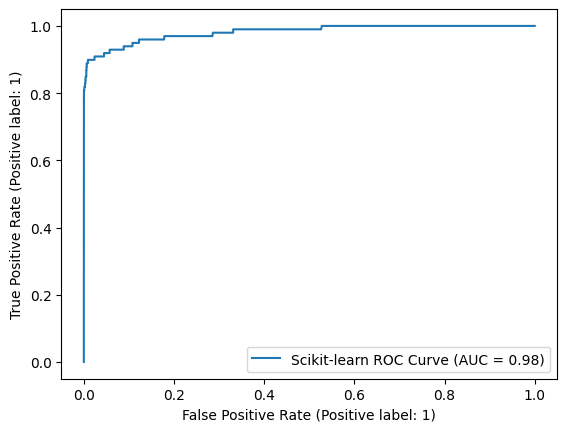

2025/12/14 23:16:44 WARNING mlflow.models.model: Model logged without a signature. Signatures will be required for upcoming model registry features as they validate model inputs and denote the expected schema of model outputs. Please visit https://www.mlflow.org/docs/2.11.4/models.html#set-signature-on-logged-model for instructions on setting a model signature on your logged model.


Run finished. UUID:  9e46fc0bf93b427b8b022831a4c4c934


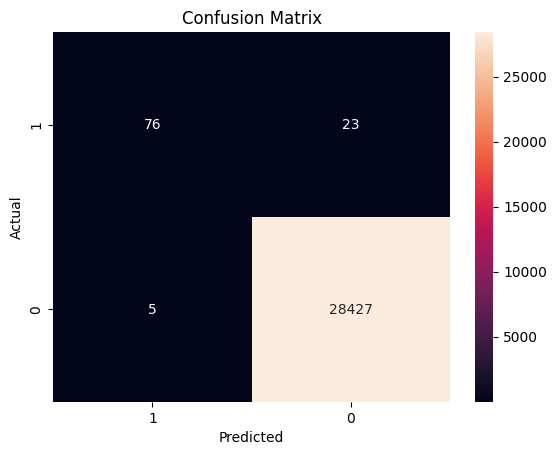

In [0]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import mlflow

rf_model = RandomForestClassifier(random_state=2020)

space = {
    'n_estimators': [10, 50],
    'max_depth': [5, 10],
    'min_samples_split': [5, 10]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=1)

search = RandomizedSearchCV(
    rf_model, 
    space, 
    n_iter=5, # Reduced to 5 for speed
    scoring='accuracy', 
    n_jobs=1,
    cv=cv, 
    random_state=1
)

print("Starting Fast Random Forest tuning...")
with mlflow.start_run(run_name="Random Forest Lite"):
    search_result = search.fit(x_train, y_train)
    best_rf_model = search_result.best_estimator_
    
    print(f"Best Params: {search_result.best_params_}")
    mlflow.log_params(search_result.best_params_)

    train(best_rf_model, x_train, y_train)
    evaluate(best_rf_model, x_test, y_test)
    
    mlflow.sklearn.log_model(best_rf_model, "random_forest_model")
    print("Run finished. UUID: ", mlflow.active_run().info.run_uuid)



![screenshot](attachments/notebook5/image.png)

![screenshot](attachments/notebook5/image2.png)

#### The Verdict: Random Forest is the Clear Winner

The Random Forest model outperformed the Logistic Regression model in every metric, particularly in the Area Under the Curve (AUC), which is the most critical metric for fraud detection.
